Сигнал sin(W1 * t) * sin(W2 * t).

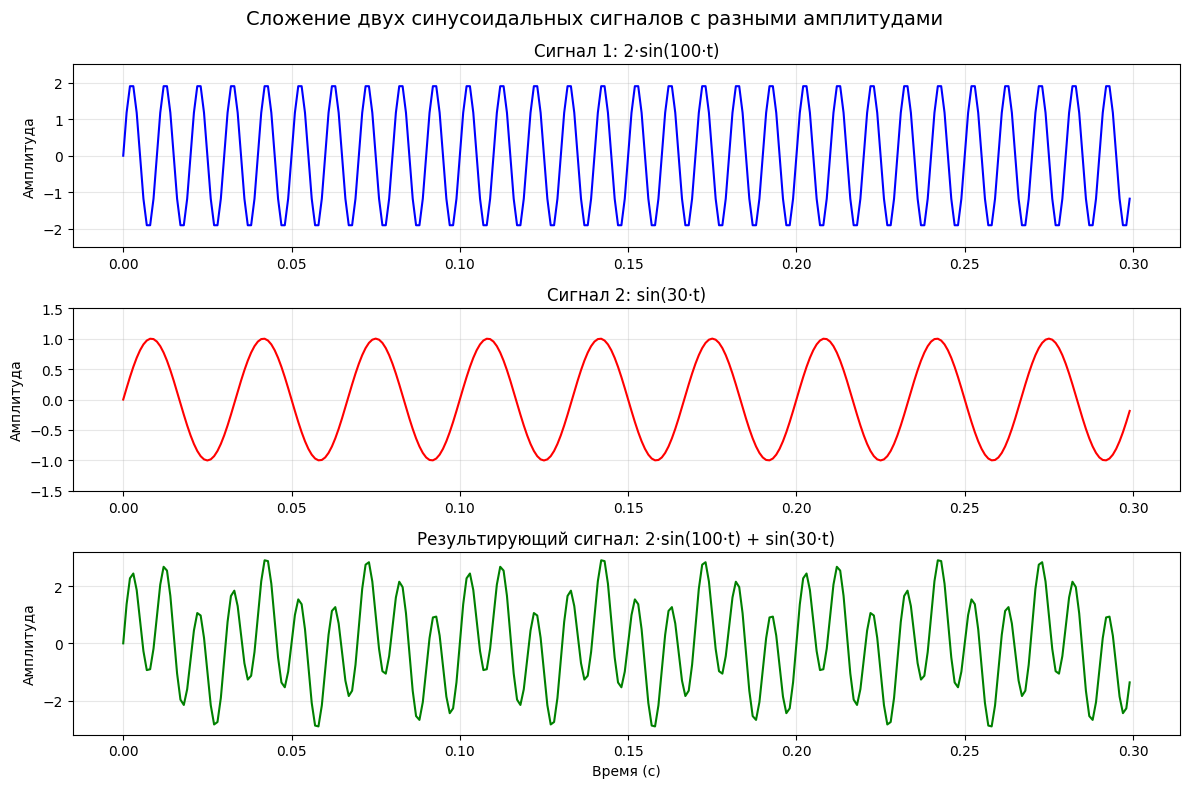

Параметры сигнала:
Частота f1 = 15.92 Гц, амплитуда A1 = 2
Частота f2 = 4.77 Гц, амплитуда A2 = 1


In [47]:
# Импортируем необходимые библиотеки
import numpy as np
import matplotlib.pyplot as plt

# Настройка отображения графиков прямо в ноутбуке
%matplotlib inline

# --- Параметры сигналов ---
W1 = 100  # Частота первого синуса (рад/с)
W2 = 30   # Частота второго синуса (рад/с)

# Переводим в герцы для спектра
f1 = W1 / (2 * np.pi)
f2 = W2 / (2 * np.pi)
# Временная шкала
t_max = 0.3  # секунд (подобрано для наглядности)
t = np.arange(0, t_max, 0.001)

# --- Формирование сигналов ---
# Сигнал 1 с амплитудой 2: 2 * sin(W1 * t)
signal1 = 2 * np.sin(2*np.pi* W1 * t) 

# Сигнал 2 с амплитудой 1: sin(W2 * t)
signal2 = np.sin(2*np.pi* W2 * t)

# Результирующий сигнал: сумма
result_signal = signal1 + signal2

# --- Построение графиков ---
plt.figure(figsize=(12, 8))

# График первого сигнала (2*sin(W1*t))
plt.subplot(3, 1, 1)
plt.plot(t, signal1, color='blue', linewidth=1.5)
plt.title(f'Сигнал 1: 2·sin({W1}·t)')
plt.ylabel('Амплитуда')
plt.grid(True, alpha=0.3)
plt.ylim(-2.5, 2.5)

# График второго сигнала (sin(W2*t))
plt.subplot(3, 1, 2)
plt.plot(t, signal2, color='red', linewidth=1.5)
plt.title(f'Сигнал 2: sin({W2}·t)')
plt.ylabel('Амплитуда')
plt.grid(True, alpha=0.3)
plt.ylim(-1.5, 1.5)

# График суммы (результата)
plt.subplot(3, 1, 3)
plt.plot(t, result_signal, color='green', linewidth=1.5)
plt.title(f'Результирующий сигнал: 2·sin({W1}·t) + sin({W2}·t)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True, alpha=0.3)

# Общий заголовок
plt.suptitle('Сложение двух синусоидальных сигналов с разными амплитудами', fontsize=14)
plt.tight_layout()
plt.show()

# --- Информация о сигнале ---
print("Параметры сигнала:")
print(f"Частота f1 = {W1/(2*np.pi):.2f} Гц, амплитуда A1 = 2")
print(f"Частота f2 = {W2/(2*np.pi):.2f} Гц, амплитуда A2 = 1")

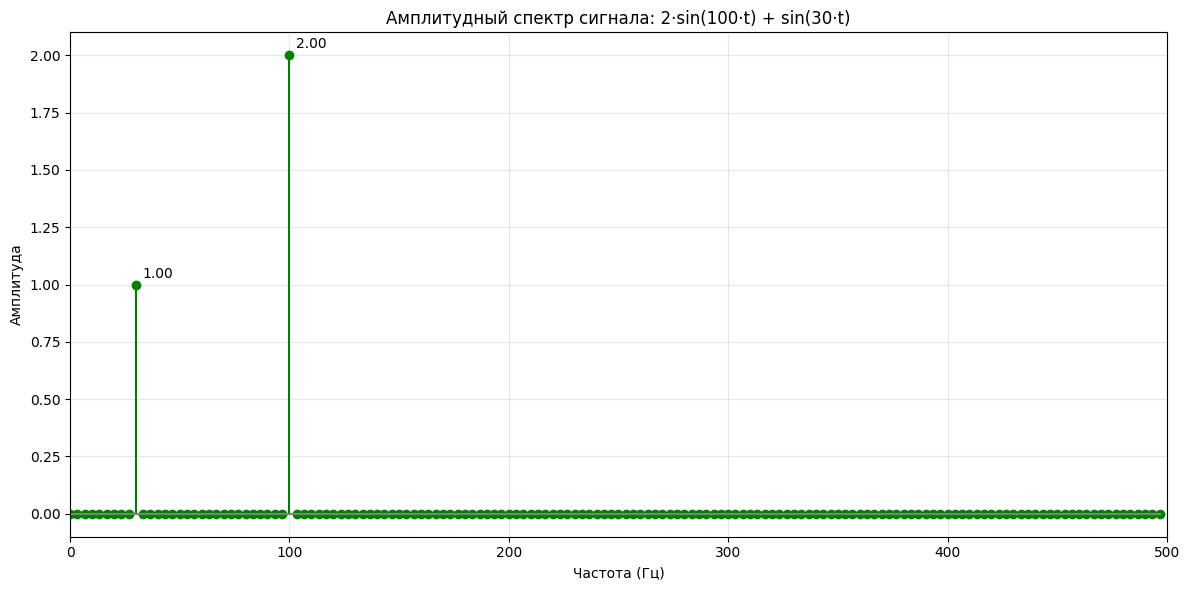

In [48]:
# --- СПЕКТР РЕЗУЛЬТИРУЮЩЕГО СИГНАЛА ---
from scipy.fft import fft, fftfreq

# Параметры для спектра
dt = t[1] - t[0]  # шаг дискретизации
n = len(result_signal)  # количество точек

# Вычисляем БПФ (быстрое преобразование Фурье)
fft_vals = fft(result_signal)
freqs = fftfreq(n, dt)

# Берем только положительные частоты (до частоты Найквиста)
positive_freqs = freqs[:n//2]
# Нормализуем амплитуды (делим на n и умножаем на 2 для одностороннего спектра)
positive_spectrum = 2.0/n * np.abs(fft_vals[:n//2])

# Создаем фигуру для спектра
plt.figure(figsize=(12, 6))

# Строим спектр
plt.stem(positive_freqs, positive_spectrum, linefmt='g-', markerfmt='go', basefmt='gray')
plt.title(f'Амплитудный спектр сигнала: 2·sin({W1}·t) + sin({W2}·t)')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.grid(True, alpha=0.3)
plt.xlim(0, 500)  # ограничиваем диапазон для наглядности

# Добавляем подписи пиков
for i, (freq, amp) in enumerate(zip(positive_freqs, positive_spectrum)):
    if amp > 0.1:  # показываем только значимые пики
        plt.annotate(f'{amp:.2f}', (freq, amp), 
                    xytext=(5, 5), textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()


# ПРоизводная

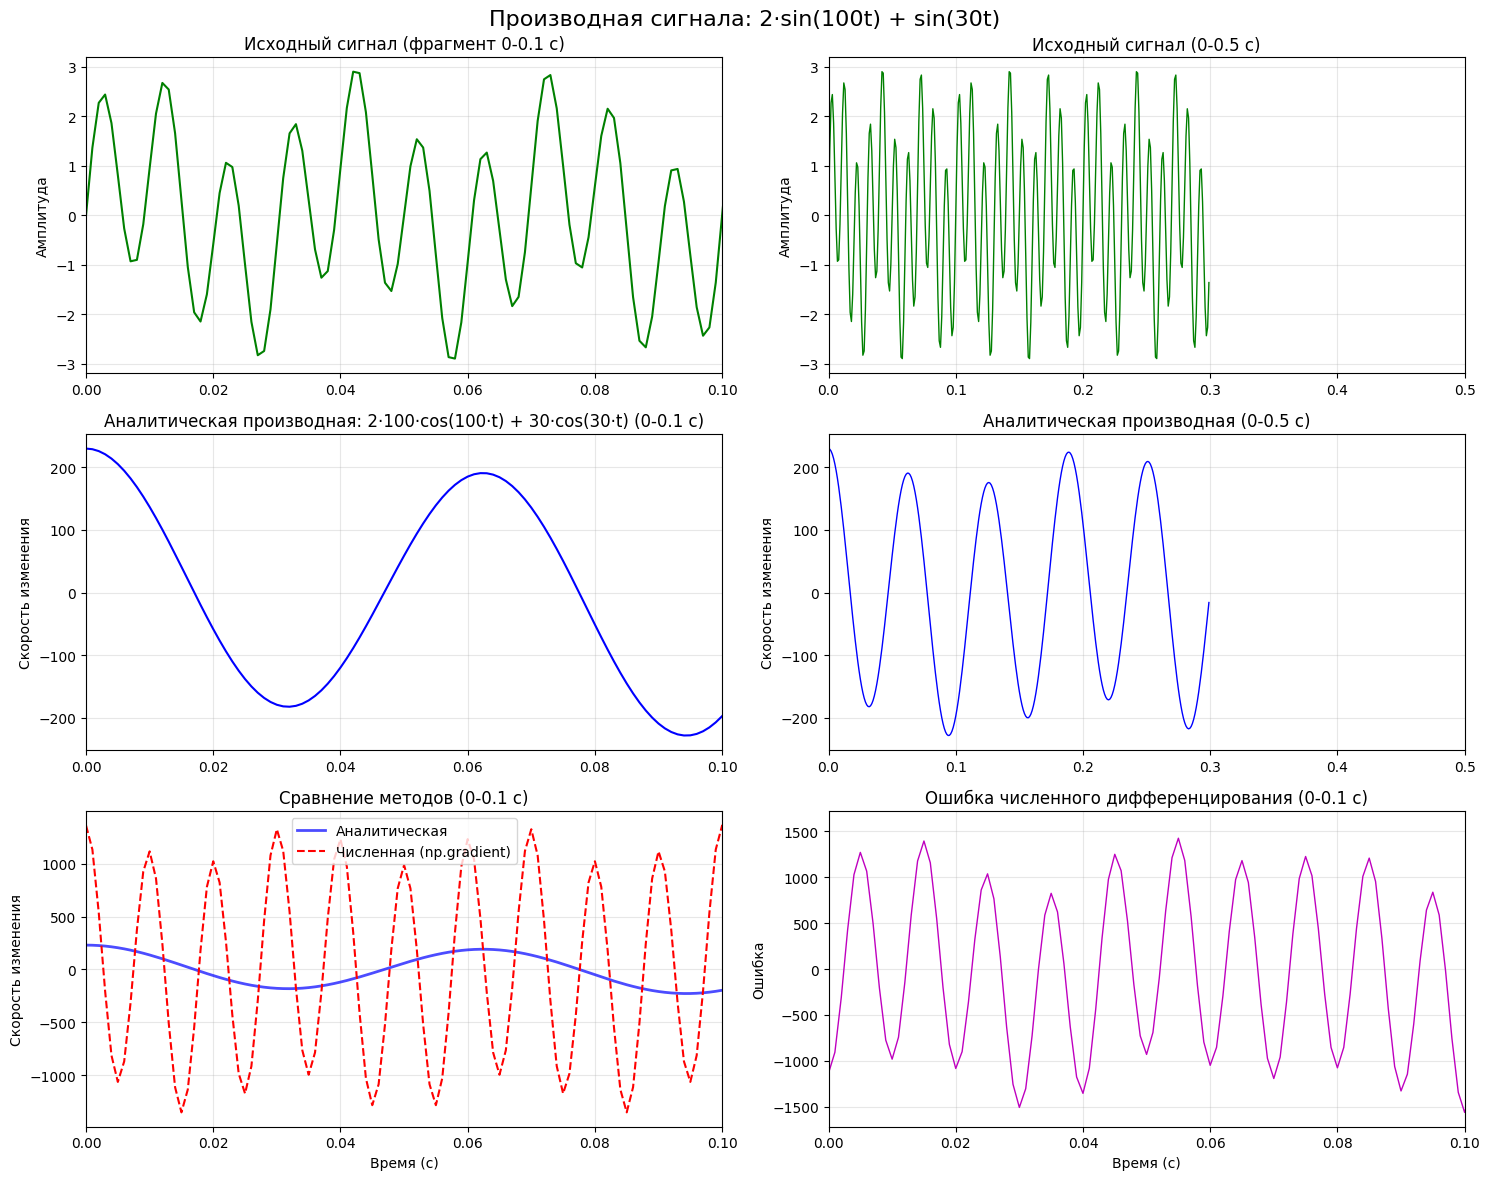


АНАЛИЗ ПРОИЗВОДНОЙ СИГНАЛА

Формула производной: 2·100·cos(100·t) + 30·cos(30·t)
Амплитуда первой гармоники (cos): 200.0
Амплитуда второй гармоники (cos): 30.0
Максимальное значение производной: 230.0
Минимальное значение производной: -228.4
Среднеквадратичная ошибка численного метода: 8.52e+02


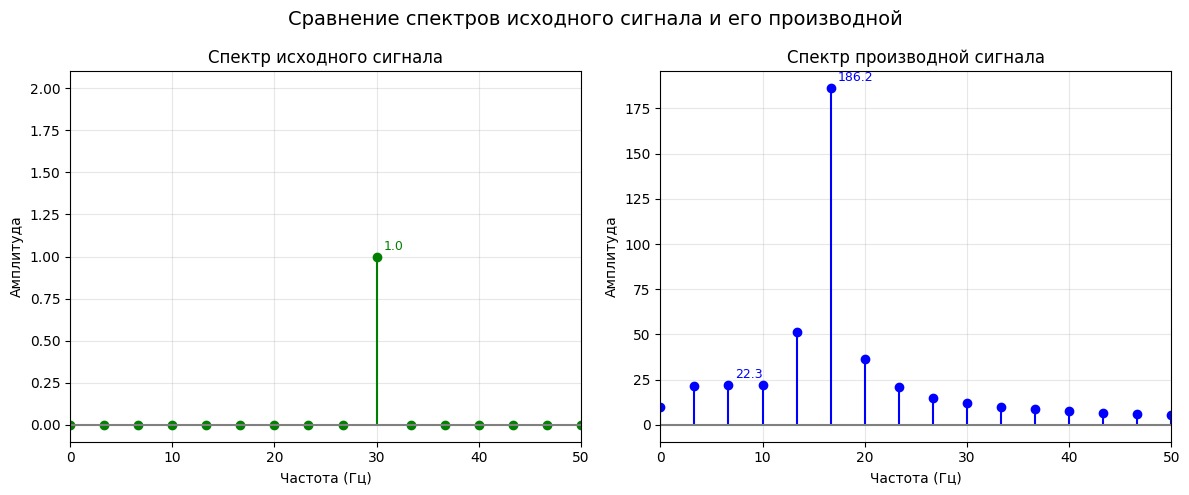


СРАВНЕНИЕ СПЕКТРОВ

Исходный сигнал:
  • Частота 15.92 Гц → амплитуда 0.00
  • Частота 4.77 Гц → амплитуда 0.00

Производная сигнала:
  • Частота 15.92 Гц → амплитуда 186.15
  • Частота 4.77 Гц → амплитуда 21.25

Изменение амплитуд:
  • На частоте 15.92 Гц: 2.0 → 200.0 (умножение на ω = 100.0)
  • На частоте 4.77 Гц: 1.0 → 30.0 (умножение на ω = 30.0)


In [49]:
# --- ПРОИЗВОДНАЯ РЕЗУЛЬТИРУЮЩЕГО СИГНАЛА ---

# Параметры (используем те же)
dt = t[1] - t[0]  # шаг дискретизации

# 1. Аналитическая производная (точная формула)
# d/dt [2·sin(W1·t) + sin(W2·t)] = 2·W1·cos(W1·t) + W2·cos(W2·t)
derivative_analytical = 2 * W1 * np.cos(W1 * t) + W2 * np.cos(W2 * t)

# 2. Численная производная (конечные разности)
derivative_numerical = np.gradient(result_signal, dt)

# Создаем фигуру для графиков производной
plt.figure(figsize=(15, 12))

# --- Исходный сигнал (для сравнения) ---
plt.subplot(3, 2, 1)
plt.plot(t[:500], result_signal[:500], 'g-', linewidth=1.5)
plt.title('Исходный сигнал (фрагмент 0-0.1 с)')
plt.ylabel('Амплитуда')
plt.grid(True, alpha=0.3)
plt.xlim(0, 0.1)

plt.subplot(3, 2, 2)
plt.plot(t[:2500], result_signal[:2500], 'g-', linewidth=1.0)
plt.title('Исходный сигнал (0-0.5 с)')
plt.ylabel('Амплитуда')
plt.grid(True, alpha=0.3)
plt.xlim(0, 0.5)

# --- Производная (аналитическая) ---
plt.subplot(3, 2, 3)
plt.plot(t[:500], derivative_analytical[:500], 'b-', linewidth=1.5)
plt.title(f'Аналитическая производная: 2·{W1}·cos({W1}·t) + {W2}·cos({W2}·t) (0-0.1 с)')
plt.ylabel('Скорость изменения')
plt.grid(True, alpha=0.3)
plt.xlim(0, 0.1)

plt.subplot(3, 2, 4)
plt.plot(t[:2500], derivative_analytical[:2500], 'b-', linewidth=1.0)
plt.title('Аналитическая производная (0-0.5 с)')
plt.ylabel('Скорость изменения')
plt.grid(True, alpha=0.3)
plt.xlim(0, 0.5)

# --- Сравнение и ошибка ---
plt.subplot(3, 2, 5)
plt.plot(t[:500], derivative_analytical[:500], 'b-', linewidth=2, label='Аналитическая', alpha=0.7)
plt.plot(t[:500], derivative_numerical[:500], 'r--', linewidth=1.5, label='Численная (np.gradient)')
plt.title('Сравнение методов (0-0.1 с)')
plt.xlabel('Время (с)')
plt.ylabel('Скорость изменения')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim(0, 0.1)

plt.subplot(3, 2, 6)
error = derivative_analytical - derivative_numerical
plt.plot(t[:500], error[:500], 'm-', linewidth=1)
plt.title('Ошибка численного дифференцирования (0-0.1 с)')
plt.xlabel('Время (с)')
plt.ylabel('Ошибка')
plt.grid(True, alpha=0.3)
plt.xlim(0, 0.1)

plt.suptitle('Производная сигнала: 2·sin(100t) + sin(30t)', fontsize=16)
plt.tight_layout()
plt.show()

# --- Анализ производной ---
print("\n" + "="*60)
print("АНАЛИЗ ПРОИЗВОДНОЙ СИГНАЛА")
print("="*60)

print(f"\nФормула производной: 2·{W1}·cos({W1}·t) + {W2}·cos({W2}·t)")
print(f"Амплитуда первой гармоники (cos): {2*W1:.1f}")
print(f"Амплитуда второй гармоники (cos): {W2:.1f}")
print(f"Максимальное значение производной: {np.max(derivative_analytical):.1f}")
print(f"Минимальное значение производной: {np.min(derivative_analytical):.1f}")
print(f"Среднеквадратичная ошибка численного метода: {np.std(error):.2e}")

# --- Спектр производной ---
plt.figure(figsize=(12, 5))

# Вычисляем спектр производной
fft_vals_deriv = fft(derivative_analytical)
positive_freqs_deriv = freqs[:n//2]  # используем те же частоты
positive_spectrum_deriv = 2.0/n * np.abs(fft_vals_deriv[:n//2])

plt.subplot(1, 2, 1)
plt.stem(positive_freqs, positive_spectrum, linefmt='g-', markerfmt='go', basefmt='gray')
plt.title('Спектр исходного сигнала')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.grid(True, alpha=0.3)
plt.xlim(0, 50)

plt.subplot(1, 2, 2)
plt.stem(positive_freqs_deriv, positive_spectrum_deriv, linefmt='b-', markerfmt='bo', basefmt='gray')
plt.title('Спектр производной сигнала')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.grid(True, alpha=0.3)
plt.xlim(0, 50)

# Добавляем подписи пиков
for ax, spectrum, color in [(plt.subplot(1,2,1), positive_spectrum, 'g'),
                            (plt.subplot(1,2,2), positive_spectrum_deriv, 'b')]:
    peaks, _ = find_peaks(spectrum, height=0.1)
    for peak in peaks:
        freq = positive_freqs[peak]
        amp = spectrum[peak]
        ax.annotate(f'{amp:.1f}', (freq, amp), 
                   xytext=(5, 5), textcoords='offset points', fontsize=9, color=color)

plt.suptitle('Сравнение спектров исходного сигнала и его производной', fontsize=14)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("СРАВНЕНИЕ СПЕКТРОВ")
print("="*60)
print(f"\nИсходный сигнал:")
print(f"  • Частота {f1:.2f} Гц → амплитуда {positive_spectrum[np.argmin(np.abs(positive_freqs - f1))]:.2f}")
print(f"  • Частота {f2:.2f} Гц → амплитуда {positive_spectrum[np.argmin(np.abs(positive_freqs - f2))]:.2f}")

print(f"\nПроизводная сигнала:")
print(f"  • Частота {f1:.2f} Гц → амплитуда {positive_spectrum_deriv[np.argmin(np.abs(positive_freqs - f1))]:.2f}")
print(f"  • Частота {f2:.2f} Гц → амплитуда {positive_spectrum_deriv[np.argmin(np.abs(positive_freqs - f2))]:.2f}")

print(f"\nИзменение амплитуд:")
print(f"  • На частоте {f1:.2f} Гц: {2.0} → {2*W1:.1f} (умножение на ω = {W1:.1f})")
print(f"  • На частоте {f2:.2f} Гц: {1.0} → {W2:.1f} (умножение на ω = {W2:.1f})")